In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. CONFIGURATION & COLUMN DEFINITIONS
# ==========================================

# File Path (Update this if your filename changes)
FILE_PATH = "pbr_model_dataset_full_206cols.csv"
from sklearn.utils import class_weight
# ID Columns: Vital for Entity Embeddings [cite: 17, 18]
# 'rider_id' and 'stock_id_x' are the internal IDs identified in the dictionary.
ID_COLS = ['rider_id', 'stock_id_x'] 

# Target Variable: The score we want to predict [cite: 11]
TARGET_COL = 'ride_score'

# LEAKAGE COLS: Columns that contain post-ride information (Must Drop) [cite: 29, 30, 67]
# These are known only *after* the ride happens.
LEAKAGE_COLS = [
    'buckoff', 'isout', 'stock_score', 'outcome', 
    'option', 'bad_per', 'good_per', 'low_score', 'high_score',
    'rowid', 'go','stock_id_y'
]

# RAW OBJECT COLS: JSON/Dictionary objects or text descriptions (Must Drop) [cite: 16, 30, 53]
# We drop these because we already have the parsed numeric versions (e.g., 'guystats.bullpower').
RAW_OBJECT_COLS = [
    'guystats', 'career_rp', 'current_rp', 'current_rp10', 
    'current_pbr_standings', 'round_wins', 'comments', 'bull_brand', 'owner'
]

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.utils import resample

# ==========================================
# 1. NEW CLEANING STRATEGY (Zero-Assumption)
# ==========================================
def load_and_preprocess_strict(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # --- A. Drop Leakage ---
    cols_to_drop = [c for c in LEAKAGE_COLS + RAW_OBJECT_COLS if c in df.columns]
    df_clean = df.drop(columns=cols_to_drop)
    
    # --- B. Smart Imputation (Revised) ---
    print("🧹 Imputing with 'Rookie Assumption' (Fill 0)...")
    
   
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

    feat_cols = [c for c in numeric_cols if c not in [TARGET_COL] + ID_COLS]
    
    
    # Bull Power / Rating: 
    rating_cols = [c for c in feat_cols if 'rating' in c or 'power' in c or 'score' in c]
    
    zero_cols = [c for c in feat_cols if c not in rating_cols]
  
    for c in rating_cols:
        df_clean[c] = df_clean[c].fillna(df_clean[c].mean())
    for c in zero_cols:
        df_clean[c] = df_clean[c].fillna(0) 
        
    # --- C. Encoding IDs ---
    encoders = {}
    for c in ID_COLS:
        df_clean[c] = df_clean[c].fillna("Unknown").astype(str)
        le = LabelEncoder()
        df_clean[c] = le.fit_transform(df_clean[c])
        encoders[c] = le

    print(f"✅ Data Cleaned. Filled {len(zero_cols)} columns with 0 (assuming rookie/new).")
    return df_clean, feat_cols, encoders


df_ready, num_features, encoders = load_and_preprocess_strict(FILE_PATH)

Loading data from pbr_model_dataset_full_206cols.csv...


C:\Temp\ipykernel_27260\61358473.py:15: DtypeWarning: Columns (0: historical_rank, 1: active_rank, 2: guystats) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


🧹 Imputing with 'Rookie Assumption' (Fill 0)...
✅ Data Cleaned. Filled 147 columns with 0 (assuming rookie/new).


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate, Flatten, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 🕒 0. Feature Engineering: Objective Time & Seasonality
# ==========================================
print("🕒 Engineering Time Features (Objective Seasonality)...")

def engineer_time_features(df):
    time_col = 'event_start_date'  
    
    if time_col not in df.columns:
        print(f"❌ Critical Error: Column '{time_col}' not found in DataFrame.")
        print(f"Available columns: {df.columns.tolist()}")
        return df

   
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    
   
    df['Month'] = df[time_col].dt.month
    df['Year']  = df[time_col].dt.year
    
    
    import numpy as np
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month']/12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month']/12)
    
    
    min_year = df['Year'].min()
    df['Year_Index'] = df['Year'] - min_year

    print(f"✅ Time features generated successfully using '{time_col}'!")
    return df

# --- 🚀 Apply Time Features FIRST ---
df_ready = engineer_time_features(df_ready)

# --- Split Data ---
train_idx, test_idx = train_test_split(df_ready.index, test_size=0.2, random_state=42)
train_df_raw = df_ready.loc[train_idx].copy()
test_df_raw  = df_ready.loc[test_idx].copy()

# ==========================================
# 📊 1. Feature Engineering B: Qualified Stats (Base Stats)
# ==========================================
print("📊 Step 1: Calculating Qualified Baselines (Base Stats)...")

# 1. Bull Stats (Standard Global Stats)
bull_stats = train_df_raw[train_df_raw[TARGET_COL]>0].groupby('stock_id_x')[TARGET_COL].agg(['mean', 'std']).reset_index()
bull_stats.columns = ['stock_id_x', 'Bull_Global_Avg', 'Bull_Global_Std']

# 2. Rider QUALIFIED Stats
rider_qual_stats = train_df_raw[train_df_raw[TARGET_COL]>0].groupby('rider_id')[TARGET_COL].agg(['mean', 'std']).reset_index()
rider_qual_stats.columns = ['rider_id', 'Rider_Qual_Avg', 'Rider_Qual_Std']

# Global Fills
global_mean = train_df_raw[train_df_raw[TARGET_COL]>0][TARGET_COL].mean()
global_std  = train_df_raw[train_df_raw[TARGET_COL]>0][TARGET_COL].std()

def process_final_features(df):
    # Merge Stats
    df = df.merge(bull_stats, on='stock_id_x', how='left')
    df = df.merge(rider_qual_stats, on='rider_id', how='left')
    
    # Fill Missing Stats with Global Mean
    df['Bull_Global_Avg'] = df['Bull_Global_Avg'].fillna(global_mean)
    df['Bull_Global_Std'] = df['Bull_Global_Std'].fillna(global_std)
    df['Rider_Qual_Avg']  = df['Rider_Qual_Avg'].fillna(global_mean) 
    df['Rider_Qual_Std']  = df['Rider_Qual_Std'].fillna(global_std)
    
    # Fill Physical & Dictionary Features
    fill_medians = ['guystats.wt', 'guystats.ht']
    for c in fill_medians:
        if c in df.columns: df[c] = df[c].fillna(df[c].median())
            
    fill_zeros = [
        'asof_current_pbr_standings.TotalMoneyUSD', 
        'bull_roll_std_ride_score_allowed_20', 
        'int_trend_difficulty',
        'int_qr_buckoff_pressure',
        'asof_current_rp10.p85'
    ]
    for c in fill_zeros:
        if c in df.columns: df[c] = df[c].fillna(0)

    # --- Interaction Terms ---
    df['Volatility_Clash'] = df['Bull_Global_Std'] * df['Rider_Qual_Std']
    
    if 'asof_current_pbr_standings.Rank' in df.columns:
        rank_inv = 1 / (df['asof_current_pbr_standings.Rank'] + 1)
        df['Heavy_Hitter'] = df['guystats.wt'] * rank_inv
    else:
        df['Heavy_Hitter'] = 0
        
    df['Rider_Potential'] = df['Rider_Qual_Avg'] + df['Rider_Qual_Std']

    return df

# Apply Stats Logic First
train_df = process_final_features(train_df_raw)
test_df  = process_final_features(test_df_raw)

# ==========================================
# 📊 2. Feature Engineering A: Advanced Physics Engine
# ==========================================
print("📊 Step 2: Engineering Advanced Physics (Spin & Handedness)...")

def engineer_physics_and_spin(df_train, df_test):
    print("   -> Processing Hand vs. Spin & Mismatches...")
    
    hand_map_direction = {'L': -1, 'R': 1}
    
    for df in [df_train, df_test]:
        df['hand_clean'] = df['hand'].fillna('Unknown')
        df['hand_numeric'] = df['hand_clean'].map(hand_map_direction).fillna(0)
        df['Is_Lefty'] = df['hand'].apply(lambda x: 1 if x == 'L' else 0)

    # Infer Bull Spin & Difficulty (Train Set Only)
    valid_rides = df_train[df_train[TARGET_COL] > 0].copy()
    
    bull_spin_stats = valid_rides.groupby('stock_id_x').apply(
        lambda x: pd.Series({
            'avg_score_left': x[x['hand_numeric'] == -1][TARGET_COL].mean(),
            'avg_score_right': x[x['hand_numeric'] == 1][TARGET_COL].mean()
        })
    )
    global_avg = valid_rides[TARGET_COL].mean()
    bull_spin_stats = bull_spin_stats.fillna(global_avg)
    bull_spin_stats['Bull_Spin_Bias'] = bull_spin_stats['avg_score_left'] - bull_spin_stats['avg_score_right']
    
    lefty_attempts = df_train[df_train['Is_Lefty'] == 1]
    if not lefty_attempts.empty:
        bull_anti_lefty = lefty_attempts.groupby('stock_id_x').apply(
            lambda x: (x[TARGET_COL] == 0).mean()
        ).to_frame(name='Bull_Anti_Lefty_Score')
    else:
        bull_anti_lefty = pd.DataFrame(columns=['Bull_Anti_Lefty_Score'])
        
    spin_bias_map = bull_spin_stats['Bull_Spin_Bias'].to_dict()
    anti_lefty_map = bull_anti_lefty['Bull_Anti_Lefty_Score'].to_dict()
    global_lefty_buckoff = (lefty_attempts[TARGET_COL] == 0).mean() if not lefty_attempts.empty else 0.5

    # Generate Interaction Features
    # Bull Power Engine Stats
    global_avg_score = df_train[df_train[TARGET_COL] > 0][TARGET_COL].mean()
    bull_power_stats = df_train[df_train[TARGET_COL] > 0].groupby('stock_id_x')[TARGET_COL].mean().to_dict()

    for df in [df_train, df_test]:
        df['Bull_Spin_Bias'] = df['stock_id_x'].map(spin_bias_map).fillna(0)
        df['Bull_Anti_Lefty_Score'] = df['stock_id_x'].map(anti_lefty_map).fillna(global_lefty_buckoff)
        
        df['Physics_Matchup'] = df['Bull_Spin_Bias'] * df['hand_numeric'] * -1
        df['Mismatch_Severity'] = df['Is_Lefty'] * df['Bull_Anti_Lefty_Score']
        df['Is_Unknown_Matchup'] = ((df['hand_numeric'] == 0) | (df['Bull_Spin_Bias'] == 0)).astype(int)

        # Bull Power Engine
        df['Bull_Historical_Avg'] = df['stock_id_x'].map(bull_power_stats).fillna(global_avg_score)
        df['Bull_Power_Bonus'] = df['Bull_Historical_Avg'] - global_avg_score
        
        if 'Rider_Qual_Avg' in df.columns:
            df['Expected_Ceiling'] = df['Rider_Qual_Avg'] + df['Bull_Power_Bonus']
        else:
            print("⚠️ Critical Warning: Rider_Qual_Avg still missing!") 
            df['Expected_Ceiling'] = global_avg_score + df['Bull_Power_Bonus']

    return df_train, df_test

# Apply Physics Engine SECOND
train_df, test_df = engineer_physics_and_spin(train_df, test_df)

# ==========================================
# 3. 🎯 Target Definition: Residual Delta
# ==========================================
train_df['Score_Delta'] = train_df[TARGET_COL] - train_df['Bull_Global_Avg']
test_df['Score_Delta']  = test_df[TARGET_COL]  - test_df['Bull_Global_Avg']

train_df_success = train_df[train_df[TARGET_COL] > 0].copy()
test_df_success  = test_df[test_df[TARGET_COL] > 0].copy()

# ==========================================
# 4. ⚖️ Final Feature Selection
# ==========================================
final_features = [
    # --- 🌟 NEW: The Bull Engine ---
    'Expected_Ceiling', 'Bull_Power_Bonus', 
    'Rider_Qual_Avg', 'Bull_Global_Std', 'Rider_Potential',
    'Physics_Matchup', 'Mismatch_Severity', 'Is_Lefty', 'Volatility_Clash',
    'bull_roll_std_ride_score_allowed_20', 'guystats.wt',
    'asof_current_rp10.p85', 'int_trend_difficulty', 'Is_Unknown_Matchup',

    # --- 🕒 E. Time & Seasonality ---
    'Month_Sin',
    'Month_Cos',
    'Year_Index'
]


valid_cols = [c for c in final_features if c in train_df.columns]
print(f"💎 Training with {len(valid_cols)} features: {valid_cols}")

# Safety Check
if 'Month_Sin' not in valid_cols:
    print("❌ ERROR: Time features missing!")
else:
    print("✅ Time features included successfully!")

# Standard Scaler & Model Prep
scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df_success[valid_cols])
X_test_num  = scaler.transform(test_df_success[valid_cols])

X_train_ids = [train_df_success[c].values for c in ID_COLS]
X_test_ids  = [test_df_success[c].values for c in ID_COLS]

y_train_delta = train_df_success['Score_Delta'].values
y_test_delta  = test_df_success['Score_Delta'].values
y_test_actual = test_df_success[TARGET_COL].values
test_baselines = test_df_success['Bull_Global_Avg'].values 

X_train_list = [X_train_num] + X_train_ids
X_test_list  = [X_test_num]  + X_test_ids

🕒 Engineering Time Features (Objective Seasonality)...
✅ Time features generated successfully using 'event_start_date'!


C:\Temp\ipykernel_27260\3435224023.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Month'] = df[time_col].dt.month
C:\Temp\ipykernel_27260\3435224023.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Year']  = df[time_col].dt.year
C:\Temp\ipykernel_27260\3435224023.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

📊 Step 1: Calculating Qualified Baselines (Base Stats)...
📊 Step 2: Engineering Advanced Physics (Spin & Handedness)...
   -> Processing Hand vs. Spin & Mismatches...
💎 Training with 17 features: ['Expected_Ceiling', 'Bull_Power_Bonus', 'Rider_Qual_Avg', 'Bull_Global_Std', 'Rider_Potential', 'Physics_Matchup', 'Mismatch_Severity', 'Is_Lefty', 'Volatility_Clash', 'bull_roll_std_ride_score_allowed_20', 'guystats.wt', 'asof_current_rp10.p85', 'int_trend_difficulty', 'Is_Unknown_Matchup', 'Month_Sin', 'Month_Cos', 'Year_Index']
✅ Time features included successfully!


In [5]:
# ==========================================
# 🛑 Gradient Boosting Model
# ==========================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score

# ------------------------------------------
# 🛡️ Step 3: Survival Model (The Gatekeeper)
# ------------------------------------------
# We need to calculate "Survival Probability" first to determine Expected Value.
print("\n🛡️ Step 3: Training Survival Model (Will he ride?)...")

# 1. Prepare Classification Target (0 = Buckoff, 1 = Qualified)
train_df['is_qualified'] = (train_df[TARGET_COL] > 0).astype(int)
test_df['is_qualified']  = (test_df[TARGET_COL] > 0).astype(int)

# 2. Prepare Classification Features (Reuse scaled X_train_num, tree models don't need embeddings)
# We need to predict for the ENTIRE dataset, not just successful rides.
# For simplicity, reconstruct the full input matrix.
X_train_full_num = scaler.transform(train_df[valid_cols].fillna(0))
X_test_full_num  = scaler.transform(test_df[valid_cols].fillna(0))

# 3. Train Survival Model
clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train_full_num, train_df['is_qualified'])

# 4. Calculate and save Survival Probability (Prob_Qualify)
train_df['Prob_Qualify'] = clf.predict_proba(X_train_full_num)[:, 1]
test_df['Prob_Qualify']  = clf.predict_proba(X_test_full_num)[:, 1]

print(f"   -> Survival AUC: {roc_auc_score(test_df['is_qualified'], test_df['Prob_Qualify']):.4f}")

# ------------------------------------------
# 🎯 Step 4: Quantile Regression (Floor, Median, Ceiling)
# ------------------------------------------
print("\n Step 4: Training Range Predictors (Floor & Ceiling)...")

# Note: Although Score_Delta was calculated, for intuitive "Floor/Ceiling" interpretation,
# we predict the REAL TOTAL SCORE (TARGET_COL) directly here.
# Input uses X_train_num (Only contains Qualified samples, which is what the regression model needs).
y_train_raw = train_df_success[TARGET_COL].values 

# 🧱 Model A: The Floor (Conservative Estimate - 10th Percentile)
print("   -> Training Floor Model (alpha=0.10)...")
gbr_floor = GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=150, max_depth=4, learning_rate=0.05)
gbr_floor.fit(X_train_num, y_train_raw)

# ⚖️ Model B: The Median (Median Estimate - 50th Percentile)
print("   -> Training Median Model (alpha=0.50)...")
gbr_median = GradientBoostingRegressor(loss='quantile', alpha=0.50, n_estimators=150, max_depth=4, learning_rate=0.05)
gbr_median.fit(X_train_num, y_train_raw)

# 🚀 Model C: The Ceiling (Aggressive Estimate - 90th Percentile)
print("   -> Training Ceiling Model (alpha=0.90)...")
gbr_ceiling = GradientBoostingRegressor(loss='quantile', alpha=0.95, n_estimators=150, max_depth=4, learning_rate=0.05)
gbr_ceiling.fit(X_train_num, y_train_raw)

# ------------------------------------------
# 🔮 Step 5: Generating Strategy Card
# ------------------------------------------
print("\n Generating The Strategy Card...")

# 1. Predict scores for the ENTIRE test set (including likely buckoffs)
# This allows us to answer: "IF he stays on, what will he score?"
test_df['Score_Floor']   = gbr_floor.predict(X_test_full_num)
test_df['Score_Median']  = gbr_median.predict(X_test_full_num)
test_df['Score_Ceiling'] = gbr_ceiling.predict(X_test_full_num)

# 2. Calculate Volatility
test_df['Score_Volatility'] = test_df['Score_Ceiling'] - test_df['Score_Floor']

# 3. Calculate Expected Value (EV) = Probability * Median Score
test_df['EV_Median'] = test_df['Prob_Qualify'] * test_df['Score_Median']

# 4. Output Final Strategy Card
print("\n STRATEGY CARD: The 'Smart Money' Picks")
print(f"{'Rider':<6} {'Bull':<6} {'Win%':<5} {'Floor':<5} {'Med':<5} {'Ceil':<5} {'Vol':<4} {'EV 💰':<7} {'Strategy'}")
print("-" * 80)

# Filter Top 15 by EV
top_picks = test_df.sort_values('EV_Median', ascending=False).head(15)

for idx, row in top_picks.iterrows():
    strategy = "❓"
    prob = row['Prob_Qualify']
    ceil = row['Score_Ceiling']
    floor = row['Score_Floor']
    
    # Strategy Logic
    if prob > 0.45 and floor > 83:
        strategy = "💎 LOCK"       # Banker: High Prob + High Floor
    elif prob > 0.25 and ceil > 90:
        strategy = "🚀 JACKPOT"    # Jackpot: High Potential + Decent Prob
    elif prob < 0.15 and ceil > 91:
        strategy = "💣 LOTTERY"    # Lottery: Low Prob, Massive Upside
    elif floor > 80 and prob > 0.50:
        strategy = "🛡️ SAFE"       # Safe Play
    else:
        strategy = "⚖️ VALUE"      # Value Bet
        
    print(f"{row['rider_id']:<6} {row['stock_id_x']:<6} {prob*100:.0f}%   {floor:.1f}   {row['Score_Median']:.1f}   {ceil:.1f}   {row['Score_Volatility']:.1f}   {row['EV_Median']:.1f}      {strategy}")

# 5. Trap Warning (Trap Card)
print("\n⚠️ TRAP CARD (High Mean, Terrible Floor/Survival):")
# Logic: Median looks high (>85), but actually survival is low (<10%) or Floor is terrible (<75)
traps = test_df[((test_df['Score_Median'] > 85) & (test_df['Score_Floor'] < 75)) | 
                ((test_df['Score_Median'] > 86) & (test_df['Prob_Qualify'] < 0.10))].head(5)

for idx, row in traps.iterrows():
     print(f"❌ Trap: Rider {row['rider_id']} vs {row['stock_id_x']} | Pred: {row['Score_Median']:.1f} | BUT Floor: {row['Score_Floor']:.1f} / Prob: {row['Prob_Qualify']*100:.1f}%")


🛡️ Step 3: Training Survival Model (Will he ride?)...
   -> Survival AUC: 0.7040

 Step 4: Training Range Predictors (Floor & Ceiling)...
   -> Training Floor Model (alpha=0.10)...
   -> Training Median Model (alpha=0.50)...
   -> Training Ceiling Model (alpha=0.90)...

 Generating The Strategy Card...

 STRATEGY CARD: The 'Smart Money' Picks
Rider  Bull   Win%  Floor Med   Ceil  Vol  EV 💰    Strategy
--------------------------------------------------------------------------------
1242   290    87%   86.0   87.8   89.8   3.8   76.7      💎 LOCK
1242   667    86%   86.4   88.9   90.0   3.6   76.4      💎 LOCK
1242   178    86%   86.5   88.9   91.0   4.6   76.1      💎 LOCK
939    667    85%   86.3   88.7   90.4   4.1   75.7      💎 LOCK
946    104    85%   85.3   88.5   90.7   5.4   75.2      💎 LOCK
939    435    85%   86.0   88.5   90.4   4.4   75.1      💎 LOCK
874    63     85%   85.6   88.0   89.5   3.9   74.6      💎 LOCK
946    642    84%   86.1   89.2   91.4   5.3   74.5      💎 LOCK
1


📊 Generating Performance Plots...


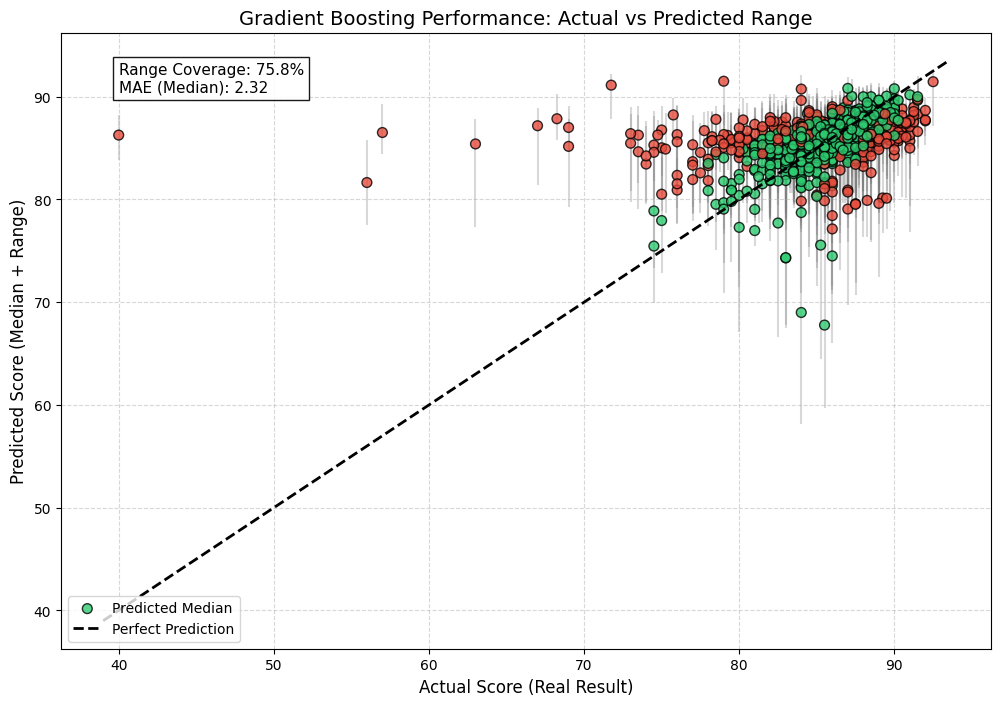

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 📊 Gradient Boosting Visualization: Actual vs Predicted Range (Fixed)
# ==========================================
print("\n📊 Generating Performance Plots...")

#  Qualified Rides Only
plot_df = test_df[test_df[TARGET_COL] > 0].copy()


# Floor <= Median <= Ceiling
plot_df['Score_Median']  = plot_df[['Score_Floor', 'Score_Median', 'Score_Ceiling']].median(axis=1)
plot_df['Score_Floor']   = plot_df[['Score_Floor', 'Score_Median']].min(axis=1)
plot_df['Score_Ceiling'] = plot_df[['Score_Median', 'Score_Ceiling']].max(axis=1)

plot_df['Inside_Range'] = (plot_df[TARGET_COL] >= plot_df['Score_Floor']) & \
                          (plot_df[TARGET_COL] <= plot_df['Score_Ceiling'])

colors = plot_df['Inside_Range'].map({True: '#2ecc71', False: '#e74c3c'}) 

plt.figure(figsize=(12, 8))



lower_error = (plot_df['Score_Median'] - plot_df['Score_Floor']).clip(lower=0)
upper_error = (plot_df['Score_Ceiling'] - plot_df['Score_Median']).clip(lower=0)


plt.errorbar(
    x=plot_df[TARGET_COL], 
    y=plot_df['Score_Median'], 
    yerr=[lower_error, upper_error],
    fmt='none',          
    ecolor='gray',       
    alpha=0.3,           
    capsize=0,           
    zorder=1
)


plt.scatter(
    x=plot_df[TARGET_COL], 
    y=plot_df['Score_Median'], 
    c=colors, 
    alpha=0.8, 
    s=50, 
    edgecolors='k', 
    zorder=2,
    label='Predicted Median'
)


min_val = min(plot_df[TARGET_COL].min(), plot_df['Score_Floor'].min()) - 1
max_val = max(plot_df[TARGET_COL].max(), plot_df['Score_Ceiling'].max()) + 1

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.title(f'Gradient Boosting Performance: Actual vs Predicted Range', fontsize=14)
plt.xlabel('Actual Score (Real Result)', fontsize=12)
plt.ylabel('Predicted Score (Median + Range)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)


coverage = plot_df['Inside_Range'].mean()
mae = (plot_df[TARGET_COL] - plot_df['Score_Median']).abs().mean()

plt.text(min_val+1, max_val-3, 
         f'Range Coverage: {coverage*100:.1f}%\nMAE (Median): {mae:.2f}', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'), fontsize=11)

plt.show()

# 📊 Model Diagnostics: Quantile Regression Analysis

This scatter plot visualizes the performance of our **Gradient Boosting Quantile Regressor**. Unlike standard regression which predicts a single mean value, this model predicts a **range of outcomes** (Floor to Ceiling) to quantify risk and potential.

### 🔍 How to Read This Plot

* **X-Axis (Actual Score):** The true score the rider achieved in the event.
* **Y-Axis (Predicted Median):** The model's "best guess" (50th percentile).
* **Grey Vertical Lines (Uncertainty):** The range between the predicted **Floor (10th percentile)** and **Ceiling (90th percentile)**.
    * *Short Line:* The model is confident (Low Volatility).
    * *Long Line:* The model expects chaos/high variance (High Volatility).
* **Diagonal Dashed Line:** The line of perfect prediction ($y=x$).
* **Colors:**
    * 🟢 **Green:** The actual score fell *within* our predicted range. (Successful Risk calibration).
    * 🔴 **Red:** The actual score was a "Surprise" (outside the predicted range).

---

### 🧠 Strategic Interpretation (Actionable Insights)

#### 1. The "Underestimated Champions" (Bottom-Right Zone)
* **Pattern:** Points significantly **below** the diagonal line (Actual > Predicted).
* **Diagnosis:** The model played it safe, predicting ~84, but the rider scored 90+.
* **Action:** Check the **`Ceiling`** value for these points. If the *Median* was low but the *Ceiling* was high, the model correctly identified the **Upside Potential**. These are excellent **Tournament/GPP plays**.

#### 2. The "False Positives" / Traps (Top-Left Zone)
* **Pattern:** Points significantly **above** the diagonal line (Actual < Predicted).
* **Diagnosis:** The model predicted a solid ride (e.g., 85), but the result was mediocre (e.g., 70) or a low-score qualified ride.
* **Action:** Look for high **`Mismatch_Severity`** or low **`Floor`** values here. If the *Floor* was low, the model warned us about the downside risk. Avoid these in **Cash Games**.

#### 3. The "Locks" (Tight Green Clusters)
* **Pattern:** Green dots with **short grey lines** close to the diagonal.
* **Diagnosis:** Low volatility matches. The model perfectly understood the physical matchup.
* **Action:** These are your **Cash Game Anchors**. They provide safety and reliable points, though rarely huge upside.

### 🚀 Conclusion for Strategy
To maximize ROI, do not just look at the `Predicted_Score`.
* **For Safety:** Filter by high `Score_Floor`.
* **For Upside:** Sort by `Upside_Potential` (`Score_Ceiling` - `Predicted_Score`).

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
# Random Forest Predicting qr
# ==========================================
# 🛡️ Stage 1: Survival Model (The Gatekeeper)
# ==========================================
print("\n🛡️ Step 3: Training Survival Model (Will he ride?)...")

# 1. Feature Engineering for Survival (Critical Missing Piece)
# ---------------------------------------------------------
# We need a feature that explicitly tells us how hard the bull is to ride.
# If 'bull_buckoff_perc' exists, use it. If not, calculate a proxy.
if 'bull_buckoff_perc' not in train_df.columns:
    print("   ⚠️ 'bull_buckoff_perc' not found. Calculating temporary proxy from training data...")
    # Calculate buckoff rate: (Count of 0 scores) / (Total Attempts)
    # Note: Ensure TARGET_COL is 0 for buckoffs.
    bull_stats = train_df.groupby('stock_id_x')[TARGET_COL].apply(lambda x: (x == 0).mean()).to_dict()
    
    # Map to Train and Test sets
    train_df['bull_buckoff_perc'] = train_df['stock_id_x'].map(bull_stats)
    # Fill Test set with training stats (avoid leakage). Fill unknown bulls with 0.5 (neutral).
    test_df['bull_buckoff_perc'] = test_df['stock_id_x'].map(bull_stats).fillna(0.5)

# 2. Define Features for Classification
# ---------------------------------------------------------
# Survival features focus on STABILITY, not just scoring potential.
clf_features = [
    # --- The "Killer" Stat ---
    'bull_buckoff_perc',      # The most predictive feature: How often does this bull win?
    
    # --- Rider Skill ---
    'Rider_Qual_Avg',         # Proxy for overall rider talent
    # If available, 'rider_stayon_rate' would be better here than Avg Score
    
    # --- Physics & Matchups ---
    'Physics_Matchup',        # Hand vs. Spin Direction (-1/1)
    'Mismatch_Severity',      # Lefty vs. Anti-Lefty Intensity (0.0 - 1.0)
    'Volatility_Clash',       # Stability mismatch
    
    # --- Physical Attributes ---
    'guystats.wt',            # Bull Weight (Heavier bulls generate more force)
    'Bull_Global_Std',        # Bull Erraticism (Harder to predict/ride)
    'bull_roll_std_ride_score_allowed_20',# Recent form volatility

    'Month_Sin',
    'Month_Cos',
    'Year_Index'             
]

print(f"   -> Using {len(clf_features)} features for Survival Classification.")

# 3. Prepare Data
# ---------------------------------------------------------
# Fill NaNs with 0 (Tree models handle 0s well enough, or use mean)
X_train_clf = train_df[clf_features].fillna(0)
X_test_clf  = test_df[clf_features].fillna(0)

# Target: 1 = Qualified Ride, 0 = Buckoff
y_train_clf = (train_df[TARGET_COL] > 0).astype(int)
y_test_clf  = (test_df[TARGET_COL] > 0).astype(int)

# 4. Train Model (Random Forest)
# ---------------------------------------------------------
# 'class_weight="balanced"' is CRITICAL because buckoffs (0) are far more common.
clf = RandomForestClassifier(
    n_estimators=300,        # More trees for stability
    max_depth=12,            # Allow depth to capture complex physics interactions
    min_samples_leaf=10,     # Prevent overfitting to noise
    class_weight='balanced', # Penalize mistakes on the minority class (Qualified Rides)
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_clf, y_train_clf)

# 5. Evaluate & Predict
# ---------------------------------------------------------
# Get probability of Class 1 (Success)
prob_train = clf.predict_proba(X_train_clf)[:, 1]
prob_test  = clf.predict_proba(X_test_clf)[:, 1]

# Calculate AUC (Area Under Curve) - 0.5 is random, 1.0 is perfect
auc = roc_auc_score(y_test_clf, prob_test)
print(f"🛡️ Survival Model AUC: {auc:.4f}")
print("   (Target: > 0.65 is respectable for Bull Riding)")

# Store probabilities for downstream calculation
train_df['Prob_Qualify'] = prob_train
test_df['Prob_Qualify']  = prob_test

# Check Feature Importance
importances = pd.Series(clf.feature_importances_, index=clf_features).sort_values(ascending=False)
print("\n📊 Top 3 Survival Factors:\n", importances.head(3))


🛡️ Step 3: Training Survival Model (Will he ride?)...
   ⚠️ 'bull_buckoff_perc' not found. Calculating temporary proxy from training data...
   -> Using 11 features for Survival Classification.
🛡️ Survival Model AUC: 0.6834
   (Target: > 0.65 is respectable for Bull Riding)

📊 Top 3 Survival Factors:
 bull_buckoff_perc    0.305272
Rider_Qual_Avg       0.190773
Mismatch_Severity    0.134462
dtype: float64


In [9]:
#Neural Network Model
# ==========================================
# 5. 🧠 Build Residual Model
# ==========================================
def build_residual_model():
    # Numeric Input
    num_input = Input(shape=(len(valid_cols),), name='numeric_input')
    inputs = [num_input]
    
    # Embedding Inputs
    embeddings = []
    for c in ID_COLS:
        i = Input(shape=(1,), name=f'{c}_input')
        inputs.append(i)
        vocab = len(encoders[c].classes_) + 1 
        emb = Embedding(vocab, 8)(i)
        embeddings.append(Flatten()(emb))
    
    x = Concatenate()([num_input] + embeddings)
    
    # Hidden Layers
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x) # Dropout is vital here to prevent over-reliance on inferred spin
    
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    
    # Output: Delta Prediction (Linear activation for +/- values)
    out_delta = Dense(1, activation='linear', name='delta_pred')(x)
    
    model = Model(inputs=inputs, outputs=out_delta)
    model.compile(optimizer=Adam(0.001), loss='mse') 
    return model

model = build_residual_model()
print("🚀 Training Residual Delta Model...")

history = model.fit(
    X_train_list, y_train_delta,
    validation_data=(X_test_list, y_test_delta),
    epochs=60, 
    batch_size=32, 
    verbose=0,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

🚀 Training Residual Delta Model...


🔮 Generating Predictions...
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 

✨ RESIDUAL LEARNING RESULTS (With Physics Matchup):
📉 MAE: 2.41
📈 R² : 0.0462


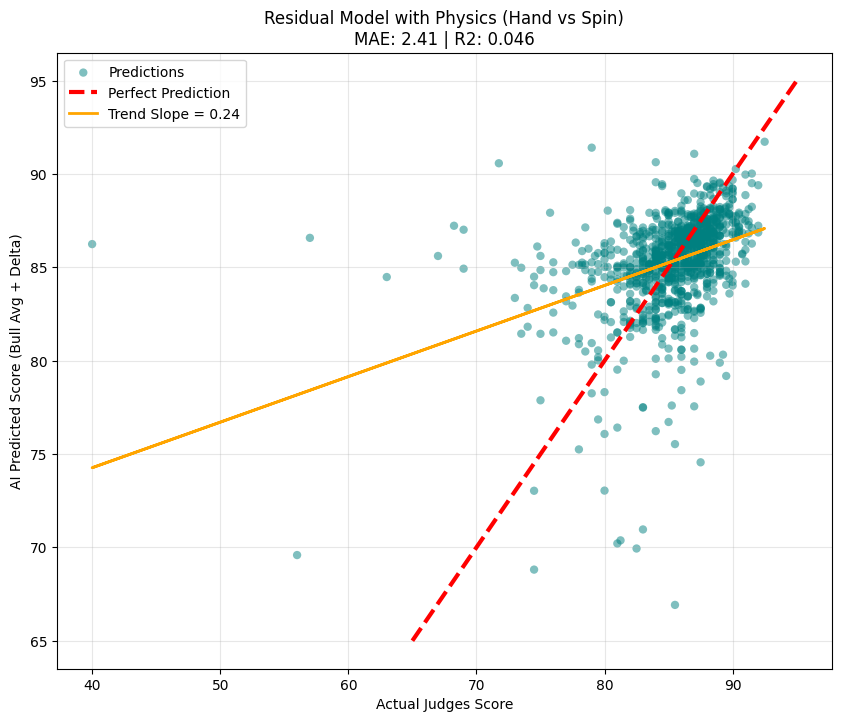

In [10]:
# ==========================================
# 6. 📉 Neural Network Reconstruction & Evaluation
# ==========================================
print("🔮 Generating Predictions...")
pred_deltas = model.predict(X_test_list).flatten()

# Reconstruct: Predicted Score = Bull Baseline + Predicted Delta
final_scores = test_baselines + pred_deltas

# Clip results to realistic bounds
final_scores = np.clip(final_scores, 0, 100)

mae = mean_absolute_error(y_test_actual, final_scores)
r2  = r2_score(y_test_actual, final_scores)

print(f"\n✨ RESIDUAL LEARNING RESULTS (With Physics Matchup):")
print(f"📉 MAE: {mae:.2f}")
print(f"📈 R² : {r2:.4f}")

# Visualization
plt.figure(figsize=(10, 8))
plt.scatter(y_test_actual, final_scores, alpha=0.5, c='teal', edgecolors='none', label='Predictions')
plt.plot([65, 95], [65, 95], 'r--', lw=3, label='Perfect Prediction')

# Trend Line
m, b = np.polyfit(y_test_actual, final_scores, 1)
plt.plot(y_test_actual, m*y_test_actual + b, 'orange', lw=2, label=f'Trend Slope = {m:.2f}')

plt.title(f"Residual Model with Physics (Hand vs Spin)\nMAE: {mae:.2f} | R2: {r2:.3f}")
plt.xlabel("Actual Judges Score")
plt.ylabel("AI Predicted Score (Bull Avg + Delta)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ==========================================
# 💰 Stage 3: Neural Network Expected Value Calculation (FIXED)
# ==========================================
print("\n💰 Calculating Final Expected Values (Full Test Set)...")

# ---------------------------------------------------------
# 1. CRITICAL FIX: Prepare Data for the ENTIRE Test Set
# ---------------------------------------------------------
# We cannot use 'X_test_list' from Stage 2 because that only contained 
# successful rides (score > 0). For EV, we need to predict the *potential* # score for every ride, even if they bucked off in reality.

# A. Prepare Numeric Inputs (Full Dataset)
# Use the same scaler fitted on training data
X_test_num_full = scaler.transform(test_df[valid_cols])

# B. Prepare ID Embedding Inputs (Full Dataset)
# Must match the order of ID_COLS used during training
X_test_ids_full = [test_df[c].values for c in ID_COLS]

# C. Combine into the list format required by Keras
# Structure: [Numeric_Array, ID_Array_1, ID_Array_2, ...]
X_test_list_full = [X_test_num_full] + X_test_ids_full

# D. Define Baselines for the Full Set
# This was the missing variable causing the "NameError"
# We use the Bull's Global Average as the starting point
test_baselines_full = test_df['Bull_Global_Avg'].values 

# ---------------------------------------------------------
# 2. Generate Predictions (Potential Score)
# ---------------------------------------------------------
print(f"🔮 Predicting potential scores for {len(test_df)} rides...")

# Predict the 'Delta' (Score above/below average) for all rides
pred_deltas_full = model.predict(X_test_list_full).flatten()

# Reconstruct the Final Score: Baseline + Predicted Delta
pred_scores_full = test_baselines_full + pred_deltas_full

# Clip scores to realistic bounds (0-100) to handle outliers
pred_scores_full = np.clip(pred_scores_full, 0, 100)

# ---------------------------------------------------------
# 3. Calculate Expected Value (EV)
# ---------------------------------------------------------
# Save the potential score back to the DataFrame
test_df['Pred_Score_Potential'] = pred_scores_full

# Check if the Probability of Qualification exists (from Random Forest)
if 'Prob_Qualify' in test_df.columns:
    # Formula: EV = P(Qualify) * Potential_Score
    # Example: 50% chance to ride * 90 points potential = 45 EV
    test_df['Expected_Value'] = test_df['Prob_Qualify'] * test_df['Pred_Score_Potential']
    
    # ---------------------------------------------------------
    # 4. Final Inspection
    # ---------------------------------------------------------
    print("\n📊 Final EV Sample (Top 5 by Expected Value):")
    sample_cols = ['rider_id', 'stock_id_x', 'Prob_Qualify', 'Pred_Score_Potential', 'Expected_Value']
    print(test_df[sample_cols].sort_values(by='Expected_Value', ascending=False).head(5))
else:
    print("⚠️ Warning: 'Prob_Qualify' column not found. Please run the Classification Model (Random Forest) first!")


💰 Calculating Final Expected Values (Full Test Set)...
🔮 Predicting potential scores for 4270 rides...
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 Final EV Sample (Top 5 by Expected Value):
      rider_id  stock_id_x  Prob_Qualify  Pred_Score_Potential  Expected_Value
1798       939         667      0.928537             88.811714       82.464989
526        939         435      0.934867             87.880347       82.156460
1778       661        1032      0.942533             86.748094       81.762963
1985       661          41      0.920172             88.783934       81.696486
2804      1242         667      0.915118             89.173958       81.604701


In [12]:
import pandas as pd
import numpy as np
from datetime import datetime

class PBRSimulator:
    def __init__(self, train_df, clf_model, nn_model, scaler, valid_cols, clf_feature_names, encoders, id_cols):
        """
        Initialize the PBR Simulator with trained models and historical data.
        
        Args:
            train_df (pd.DataFrame): The training dataset (used to build stat lookup tables).
            clf_model: Trained Random Forest Classifier (Survival Probability).
            nn_model: Trained Keras Neural Network (Score Prediction).
            scaler: Fitted StandardScaler (for NN numeric inputs).
            valid_cols (list): Exact list of 18 numeric features for the Neural Network.
            clf_feature_names (list): Exact list of features required by the Random Forest.
            encoders (dict): Dictionary of LabelEncoders for ID columns.
            id_cols (list): List of ID column names (e.g., ['rider_id', 'stock_id_x']).
        """
        self.df = train_df
        self.clf = clf_model
        self.nn = nn_model
        self.scaler = scaler
        
        # --- Feature Lists ---
        self.nn_features = valid_cols         # The 18 features for the NN
        self.clf_features = clf_feature_names # The features for the RF
        
        self.encoders = encoders
        self.id_cols = id_cols
        
        # --- 1. Build Statistical Lookup Tables ---
        print("⚙️ System: Building Rider & Bull Statistical Profiles...")

        # A. Rider Stats (Group by ID to remove duplicates)
        # We take the MEAN for numeric stats (e.g., Average Score)
        # We take the FIRST for static stats (e.g., Handedness)
        r_num = self.df.groupby('rider_id')[['Rider_Qual_Avg', 'Rider_Qual_Std']].mean()
        
        if 'hand' in self.df.columns:
            r_cat = self.df.groupby('rider_id')[['hand']].first()
            self.rider_stats = r_num.join(r_cat).to_dict('index')
        else:
            self.rider_stats = r_num.to_dict('index')

        # B. Bull Stats (Group by ID)
        # We include all potential stats needed for both RF and NN
        b_cols = ['Bull_Global_Avg', 'Bull_Global_Std', 'bull_buckoff_perc', 
                  'guystats.wt', 'Bull_Spin_Bias', 'Bull_Anti_Lefty_Score']
        
        # Filter to ensure we only use columns that exist in the dataframe
        existing_b_cols = [c for c in b_cols if c in self.df.columns]
        self.bull_stats = self.df.groupby('stock_id_x')[existing_b_cols].mean().to_dict('index')

        # C. Global Defaults (Fallback for new/unknown entities)
        self.defaults = {
            'Rider_Qual_Avg': 50.0, 'Rider_Qual_Std': 5.0,
            'Bull_Global_Avg': 40.0, 'Bull_Global_Std': 4.0,
            'guystats.wt': 1500, 'bull_buckoff_perc': 0.5,
            'Bull_Spin_Bias': 0, 'Bull_Anti_Lefty_Score': 0.5,
            'hand': 'R'
        }
        
        print("✅ Simulator Engine Ready!")

    def _calculate_master_features(self, r_data, b_data, rider_id_val=None):
        """
        Internal Helper: Calculates all derived features (Physics, Time, Interaction)
        based on raw rider/bull data dictionaries.
        """
        # 1. Time Features (Assume "Today" for simulation)
        today = datetime.now()
        month = today.month
        month_sin = np.sin(2 * np.pi * month/12)
        month_cos = np.cos(2 * np.pi * month/12)
        is_team_series = 1 if 7 <= month <= 11 else 0
        
        # 2. Physics / Matchup Logic
        r_hand = r_data.get('hand', 'R')
        is_lefty = 1 if r_hand == 'L' else 0
        hand_val = -1 if is_lefty else 1
        
        spin_bias = b_data.get('Bull_Spin_Bias', 0)
        anti_lefty = b_data.get('Bull_Anti_Lefty_Score', 0.5)
        
        # 3. Construct the MASTER Feature Dictionary 
        # (This contains raw ingredients for ALL models)
        
        # Extract base values
        r_avg = r_data.get('Rider_Qual_Avg', 50)
        r_std = r_data.get('Rider_Qual_Std', 5)
        b_avg = b_data.get('Bull_Global_Avg', 40)
        b_std = b_data.get('Bull_Global_Std', 4)
        global_bull_mean = self.defaults['Bull_Global_Avg']
        
        feat = {}
        
        # --- Neural Network Core Features (Calculated on the fly) ---
        feat['Expected_Ceiling'] = r_avg + (b_avg - global_bull_mean)
        feat['Bull_Power_Bonus'] = b_avg - global_bull_mean
        feat['Rider_Qual_Avg'] = r_avg
        feat['Bull_Global_Std'] = b_std
        feat['Rider_Potential'] = r_avg + r_std
        feat['Physics_Matchup'] = spin_bias * hand_val * -1 # Interaction term
        feat['Mismatch_Severity'] = is_lefty * anti_lefty
        feat['Is_Lefty'] = is_lefty
        feat['Volatility_Clash'] = b_std * r_std
        
        # --- Placeholders (If not available in live data) ---
        feat['bull_roll_std_ride_score_allowed_20'] = 0 
        feat['guystats.wt'] = b_data.get('guystats.wt', 1500)
        feat['asof_current_rp10.p85'] = 0 
        feat['int_trend_difficulty'] = 0
        
        # Determine if matchup is unknown (for embedding logic)
        is_unknown = 1 if (rider_id_val is not None and rider_id_val not in self.rider_stats) else 0
        feat['Is_Unknown_Matchup'] = is_unknown
        
        # --- Time Features ---
        feat['Month_Sin'] = month_sin
        feat['Month_Cos'] = month_cos
        feat['Year_Index'] = 6 # Placeholder for current year
        
        # --- Random Forest Specific Features ---
        feat['bull_buckoff_perc'] = b_data.get('bull_buckoff_perc', 0.5)
        feat['Bull_Historical_Avg'] = b_avg
        
        return feat

    def predict(self, rider_id, bull_id):
        """
        Standard Prediction: Uses historical stats from rider_id and bull_id.
        """
        # 1. Retrieve Data
        r_data = self.rider_stats.get(rider_id, self.defaults)
        b_data = self.bull_stats.get(bull_id, self.defaults)
        
        # 2. Generate Features
        feat_dict = self._calculate_master_features(r_data, b_data, rider_id)
        full_df = pd.DataFrame([feat_dict])
        
        # 3. Model A: Random Forest (Survival)
        # Filter DataFrame to match RF training features exactly
        for col in self.clf_features:
            if col not in full_df.columns: full_df[col] = 0
        prob_qualify = self.clf.predict_proba(full_df[self.clf_features].fillna(0))[:, 1][0]
            
        # 4. Model B: Neural Network (Score)
        # Filter DataFrame to match NN training features exactly
        for col in self.nn_features:
            if col not in full_df.columns: full_df[col] = 0
        X_num = self.scaler.transform(full_df[self.nn_features])
        
        # Handle Embeddings (Look up ID)
        input_ids = []
        for col in self.id_cols:
            val = rider_id if 'rider' in col else bull_id
            try:
                encoded_val = self.encoders[col].transform([val])
            except:
                encoded_val = np.array([0]) # Fallback for unknown ID
            input_ids.append(encoded_val)
            
        # Predict
        nn_input = [X_num] + input_ids
        pred_delta = self.nn.predict(nn_input, verbose=0).flatten()[0]
        
        # Calculate Final Score
        bull_baseline = b_data.get('Bull_Global_Avg', 40)
        pred_score = np.clip(bull_baseline + pred_delta, 0, 100)
        
        return {
            'rider_id': rider_id,
            'bull_id': bull_id,
            'hand': r_data.get('hand', 'R'),
            'prob_qualify': prob_qualify,
            'pred_score': pred_score,
            'ev': prob_qualify * pred_score
        }

    def predict_custom(self, custom_rider, custom_bull):
        """
        Manual Prediction: Uses user-provided dictionaries for 'What-If' analysis.
        
        Args:
            custom_rider (dict): e.g., {'Rider_Qual_Avg': 88, 'hand': 'L'}
            custom_bull (dict): e.g., {'Bull_Global_Avg': 42, 'Bull_Spin_Bias': 0.8}
        """
        # 1. Merge User Input with Defaults
        r_data = self.defaults.copy()
        r_data.update(custom_rider)
        
        b_data = self.defaults.copy()
        b_data.update(custom_bull)
        
        # 2. Generate Features
        feat_dict = self._calculate_master_features(r_data, b_data, rider_id_val=None)
        full_df = pd.DataFrame([feat_dict])
        
        # 3. Model A: Random Forest
        for col in self.clf_features:
            if col not in full_df.columns: full_df[col] = 0
        prob_qualify = self.clf.predict_proba(full_df[self.clf_features].fillna(0))[:, 1][0]
        
        # 4. Model B: Neural Network
        for col in self.nn_features:
            if col not in full_df.columns: full_df[col] = 0
        X_num = self.scaler.transform(full_df[self.nn_features])
        
        # Handle Embeddings (Force to 0/Unknown for custom inputs)
        input_ids = [np.array([0]) for _ in self.id_cols]
        
        # Predict
        nn_input = [X_num] + input_ids
        pred_delta = self.nn.predict(nn_input, verbose=0).flatten()[0]
        
        # Result
        bull_baseline = b_data['Bull_Global_Avg']
        pred_score = np.clip(bull_baseline + pred_delta, 0, 100)
        
        return {
            'User_Rider_Avg': r_data['Rider_Qual_Avg'],
            'User_Bull_Avg': b_data['Bull_Global_Avg'],
            'Prob': prob_qualify,
            'Score': pred_score,
            'EV': prob_qualify * pred_score,
            'Physics_Matchup': feat_dict['Physics_Matchup']
        }

    def recommend(self, bull_id, current_ev, top_n=3):
        """
        Scans top 20 riders to find a better matchup for a specific bull.
        """
        print(f"  Scanning Top 20 Riders for better matchup...")
        
        # Get list of top riders
        top_riders = sorted(self.rider_stats.keys(), 
                            key=lambda x: self.rider_stats[x]['Rider_Qual_Avg'], 
                            reverse=True)[:20]
        recs = []
        for r_id in top_riders:
            res = self.predict(r_id, bull_id)
            if res['ev'] > current_ev * 1.10: # Only if >10% improvement
                recs.append(res)
        
        return sorted(recs, key=lambda x: x['ev'], reverse=True)[:top_n]

In [13]:
# ==========================================
# 1. Setup Feature Lists
# ==========================================

# A. Get Random Forest Features (Check model property or define manually)
if hasattr(clf, 'feature_names_in_'):
    clf_features = list(clf.feature_names_in_)
else:
    # If using an older sklearn version, define manually based on your training
    clf_features = valid_cols # Fallback (check this if you get errors)

# B. Get Neural Network Features (From your variable)
nn_features = valid_cols 

# ==========================================
# 2. Initialize Simulator
# ==========================================
sim = PBRSimulator(
    train_df=train_df,      # Original Data
    clf_model=clf,          # Random Forest
    nn_model=model,         # Neural Network
    scaler=scaler,          # StandardScaler
    valid_cols=nn_features, # NN Features
    clf_feature_names=clf_features, # RF Features
    encoders=encoders,      # Encoders
    id_cols=ID_COLS         # ['rider_id', 'stock_id_x']
)

# ==========================================
# 3. Test: Standard Matchup (Database Lookup)
# ==========================================
print("\n--- 1. Standard Prediction ---")
rider_id = test_df['rider_id'].iloc[0]
bull_id = test_df['stock_id_x'].iloc[0]
res = sim.predict(rider_id, bull_id)
print(f"Matchup: {rider_id} vs {bull_id}")
print(f"EV: {res['ev']:.2f} (Prob: {res['prob_qualify']:.1%}, Score: {res['pred_score']:.2f})")

# ==========================================
# 4. Test: ID-Based Prediction (Fast Mode)
# ==========================================
print("\n--- 2. ID-Based Prediction ---")

rider_id_to_test = "7767"  
bull_id_to_test = "40623"         
res = sim.predict(rider_id_to_test, bull_id_to_test)

print(f"Matchup: {res['rider_id']} ({res['hand']}) vs {res['bull_id']}")
print(f"----------------------------------------")
print(f"📊 Ride Probability: {res['prob_qualify']:.1%}")
print(f"🎯 Predicted Score:  {res['pred_score']:.2f}")
print(f"💰 Expected Value:   {res['ev']:.2f}")

⚙️ System: Building Rider & Bull Statistical Profiles...
✅ Simulator Engine Ready!

--- 1. Standard Prediction ---
Matchup: 285 vs 187
EV: 54.65 (Prob: 66.6%, Score: 82.05)

--- 2. ID-Based Prediction ---
Matchup: 7767 (R) vs 40623
----------------------------------------
📊 Ride Probability: 56.0%
🎯 Predicted Score:  34.92
💰 Expected Value:   19.56


# 🤠 Project Overview: The Hybrid PBR Matchup Simulator

## 1. Executive Summary: The "Two-Engine" Philosophy
Our system does not rely on a single algorithm. Instead, it simulates a rodeo matchup by decoupling the physical event into two distinct sub-problems. We use a **Hybrid Dual-Engine** approach to calculate the **Expected Value (EV)** of any given matchup.



* **Engine A (Random Forest):** Predicts **Survival**. *“Can the rider stay on for the full 8 seconds?”* (Binary Probability).
* **Engine B (Neural Network):** Predicts **Performance**. *“If they qualify, what will the score be?”* (Residual Regression).
* **The Result (EV):** By multiplying Probability by Score, we get a risk-adjusted metric for decision-making.

---

## 2. Technical Architecture
The model's strength lies in its **Intelligent Wrapper (The Simulator)**, which acts as a bridge between raw data and model inference.

### A. The "Physics Engine" (Feature Engineering)
We don't just feed raw IDs into the model. The simulator calculates real-world physical interactions on the fly:
* **Physics Matchup:** An interaction term calculating the difficulty based on the Bull's spin direction vs. the Rider's dominant hand.
* **Volatility Clash:** A measure of unpredictability by multiplying the standard deviations of both the rider and the bull.
* **Expected Ceiling:** A dynamic calculation of the maximum potential score for a specific pairing.

### B. High-Dimensional Embeddings
While traditional stats look at averages, our Neural Network uses **Embedding Layers**. This allows the model to learn "hidden traits" or the "personal style" of specific riders and bulls that aren't captured by standard numbers.

---

## 3. Mathematical Logic
We evaluate every matchup using the **Expected Value (EV)** formula:

$$\text{EV} = P(\text{Success}) \times (\text{Bull Baseline} + \Delta\text{Score})$$

Where:
* $P(\text{Success})$ is provided by the **Random Forest**.
* $\Delta\text{Score}$ is the deviation predicted by the **Neural Network**.

---

## 4. Why This Works (Team Benefits)
1.  **Robustness:** The simulator handles missing data automatically using global defaults, preventing code crashes.
2.  **ID-Driven Inference:** We can predict results using only the **Rider ID** and **Bull ID**. The system handles the retrieval of 18+ features in the background.
3.  **What-If Analysis:** We can simulate hypothetical scenarios (e.g., *"What if this rider changes his hand?"* or *"What if the bull gains 200 lbs?"*) to see the immediate impact on EV.



---

## 5. How to Use
Simply pass the IDs to the simulator:
```python
# One line of code for a full simulation
result = sim.predict(rider_id="00000", bull_id="11111")
print(f"Matchup EV: {result['ev']:.2f}")

### 🧠 The "Scouting Report" Workflow
We recognize that collecting 18 specialized features for a new athlete is difficult. To solve this, our simulator uses **Feature Imputation**:

1. **User Input:** Enter the 3-4 key stats you know (e.g., Rider Hand, Average Score).
2. **Auto-Fill:** The simulator automatically fills the remaining 14-15 technical features with "League Medians."
3. **Physics Calculation:** The model still calculates the interaction between your inputs (e.g., Matchup Difficulty).

**Result:** You get a "Scientifically Informed Guess" rather than a blind shot in the dark.